In [1]:
%matplotlib inline
%load_ext autoreload
%autoreload 2

import os
import copy
import glob
import warnings

import healpy
import fitsio

import numpy as np 

import astropy.units as u
from astropy.io import fits
from astropy.wcs import WCS
from astropy.coordinates import SkyCoord
from astropy.table import Table, Column, vstack

import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
from matplotlib.patches import Polygon
from matplotlib.collections import PatchCollection

warnings.filterwarnings('ignore', category=UserWarning, append=True)

In [42]:
import corner

import pandas as pd
from pandas.plotting import scatter_matrix

In [9]:
from sklearn import manifold, datasets

#### Combined catalog for HSC `S20A`

In [2]:
gaia_dir = '/Users/song/Downloads/gaia_edr3_hsc/'

s20a_edr3 = Table.read(os.path.join(gaia_dir, 'gaia_edr3_hsc_s20a_fdfc.fits'))

#### Select objects with useful information

- Only keep the faint ones
- Remove the ones with obvious parallax and proper motion
- Remove duplicated source
- Keep the ones with useful photometric information

In [6]:
mask = (
    (s20a_edr3['phot_g_mean_mag'] >= 17.2) &
    np.isfinite(s20a_edr3['phot_g_mean_mag']) &
    np.isfinite(s20a_edr3['phot_bp_rp_excess_factor']) &
    np.isfinite(s20a_edr3['ruwe']) &
    np.isfinite(s20a_edr3['astrometric_excess_noise']) &
    np.isfinite(s20a_edr3['scan_direction_strength_k1']) & 
    np.isfinite(s20a_edr3['scan_direction_strength_k2']) &
    np.isfinite(s20a_edr3['scan_direction_strength_k3']) &
    np.isfinite(s20a_edr3['scan_direction_strength_k4']) &
    np.isfinite(s20a_edr3['scan_direction_mean_k1']) & 
    np.isfinite(s20a_edr3['scan_direction_mean_k2']) &
    np.isfinite(s20a_edr3['scan_direction_mean_k3']) &
    np.isfinite(s20a_edr3['scan_direction_mean_k4']) & 
    (~s20a_edr3['duplicated_source']) &
    (s20a_edr3['parallax_over_error'] <= 40) & 
    (np.abs(s20a_edr3['pmra'] / s20a_edr3['pmra_error']) <= 100) &
    (np.abs(s20a_edr3['pmdec'] / s20a_edr3['pmdec_error']) <= 100)
)

print(mask.sum() / len(s20a_edr3))

hsc_use = s20a_edr3[mask]

0.5760110315401353


In [68]:
mask.sum()

1542220

In [ ]:
hsc_use = s20a_edr3[mask]

In [63]:
col_used = [
    'ra_error', 'dec_error', 'parallax', 'parallax_over_error', 
    'pm', 'pmra', 'pmra_error', 'pmdec', 'pmdec_error', 
    'ra_dec_corr', 'ra_parallax_corr', 'ra_pmra_corr', 'ra_pmdec_corr', 'dec_parallax_corr', 
    'dec_pmra_corr', 'dec_pmdec_corr', 'parallax_pmra_corr', 
    'parallax_pmdec_corr', 'pmra_pmdec_corr',
    'astrometric_excess_noise', 'astrometric_excess_noise_sig', 'astrometric_sigma5d_max',
    'scan_direction_strength_k1', 'scan_direction_strength_k2', 
    'scan_direction_strength_k3', 'scan_direction_strength_k4', 
    'scan_direction_mean_k1', 'scan_direction_mean_k2', 'scan_direction_mean_k3', 
    'scan_direction_mean_k4', 'phot_g_mean_mag', 'phot_bp_mean_mag', 
    'phot_rp_mean_mag', 'bp_rp', 'bp_g', 'g_rp',
    'log_chi2', 'log_ruwe', 'log_g_s2n', 'log_bp_s2n', 'log_rp_s2n', 'log_phot_excess',
    'log_ipd_harmonic', 'log_sigma5d_max'
]

In [57]:
log_chi2 = np.log10(hsc_use['astrometric_chi2_al'])
log_ruwe = np.log10(hsc_use['ruwe'])
log_g_s2n = np.log10(hsc_use['phot_g_mean_flux_over_error'])
log_bp_s2n = np.log10(hsc_use['phot_bp_mean_flux_over_error'])
log_rp_s2n = np.log10(hsc_use['phot_rp_mean_flux_over_error'])
log_phot_excess = np.log10(hsc_use['phot_bp_rp_excess_factor'])
log_ipd_harmonic = np.log10(hsc_use['ipd_gof_harmonic_amplitude'])
log_sigma5d_max = np.log10(hsc_use['astrometric_sigma5d_max'])

hsc_use.add_column(Column(data=log_chi2, name='log_chi2'))
hsc_use.add_column(Column(data=log_ruwe, name='log_ruwe'))
hsc_use.add_column(Column(data=log_g_s2n, name='log_g_s2n'))
hsc_use.add_column(Column(data=log_bp_s2n, name='log_bp_s2n'))
hsc_use.add_column(Column(data=log_rp_s2n, name='log_rp_s2n'))
hsc_use.add_column(Column(data=log_phot_excess, name='log_phot_excess'))
hsc_use.add_column(Column(data=log_ipd_harmonic, name='log_ipd_harmonic'))
hsc_use.add_column(Column(data=log_sigma5d_max, name='log_sigma5d_max'))

- A dimensionless measure (D) of the significance of the calculated astrometric_excess_noise (ϵi). A value D>2 indicates that the given ϵi is probably significant.

In [70]:
(hsc_use['astrometric_excess_noise_sig'] >= 1.5).sum()

241796

In [64]:
for col in col_used:
    print("{:40s} {:15.6f} {:15.6f} {:15.6f} {:15.6f}".format(
        col, np.min(hsc_use[col]), np.max(hsc_use[col]), np.nanmin(hsc_use[col]), np.nanmax(hsc_use[col])))

ra_error                                        0.037371        3.605064        0.037371        3.605064
dec_error                                       0.029655        3.472133        0.029655        3.472133
parallax                                      -35.077376       22.861909      -35.077376       22.861909
parallax_over_error                           -17.005423       39.962250      -17.005423       39.962250
pm                                              0.002349      247.134415        0.002349      247.134415
pmra                                         -246.849646      163.335044     -246.849646      163.335044
pmra_error                                      0.045071        3.389083        0.045071        3.389083
pmdec                                        -187.775945       74.196599     -187.775945       74.196599
pmdec_error                                     0.045906        3.349685        0.045906        3.349685
ra_dec_corr                                    -0.94786

#### Convert the catalog into Pandas dataframe and Numpy array

In [91]:
hsc_ml = hsc_use[hsc_use['astrometric_excess_noise_sig'] >= 2.0]

hsc_ml = hsc_ml[col_used]

hsc_ml_data = hsc_ml.to_pandas()

hsc_ml_arr = np.asarray(hsc_ml_data)

In [92]:
from matplotlib import rc
rc('text', usetex=False)

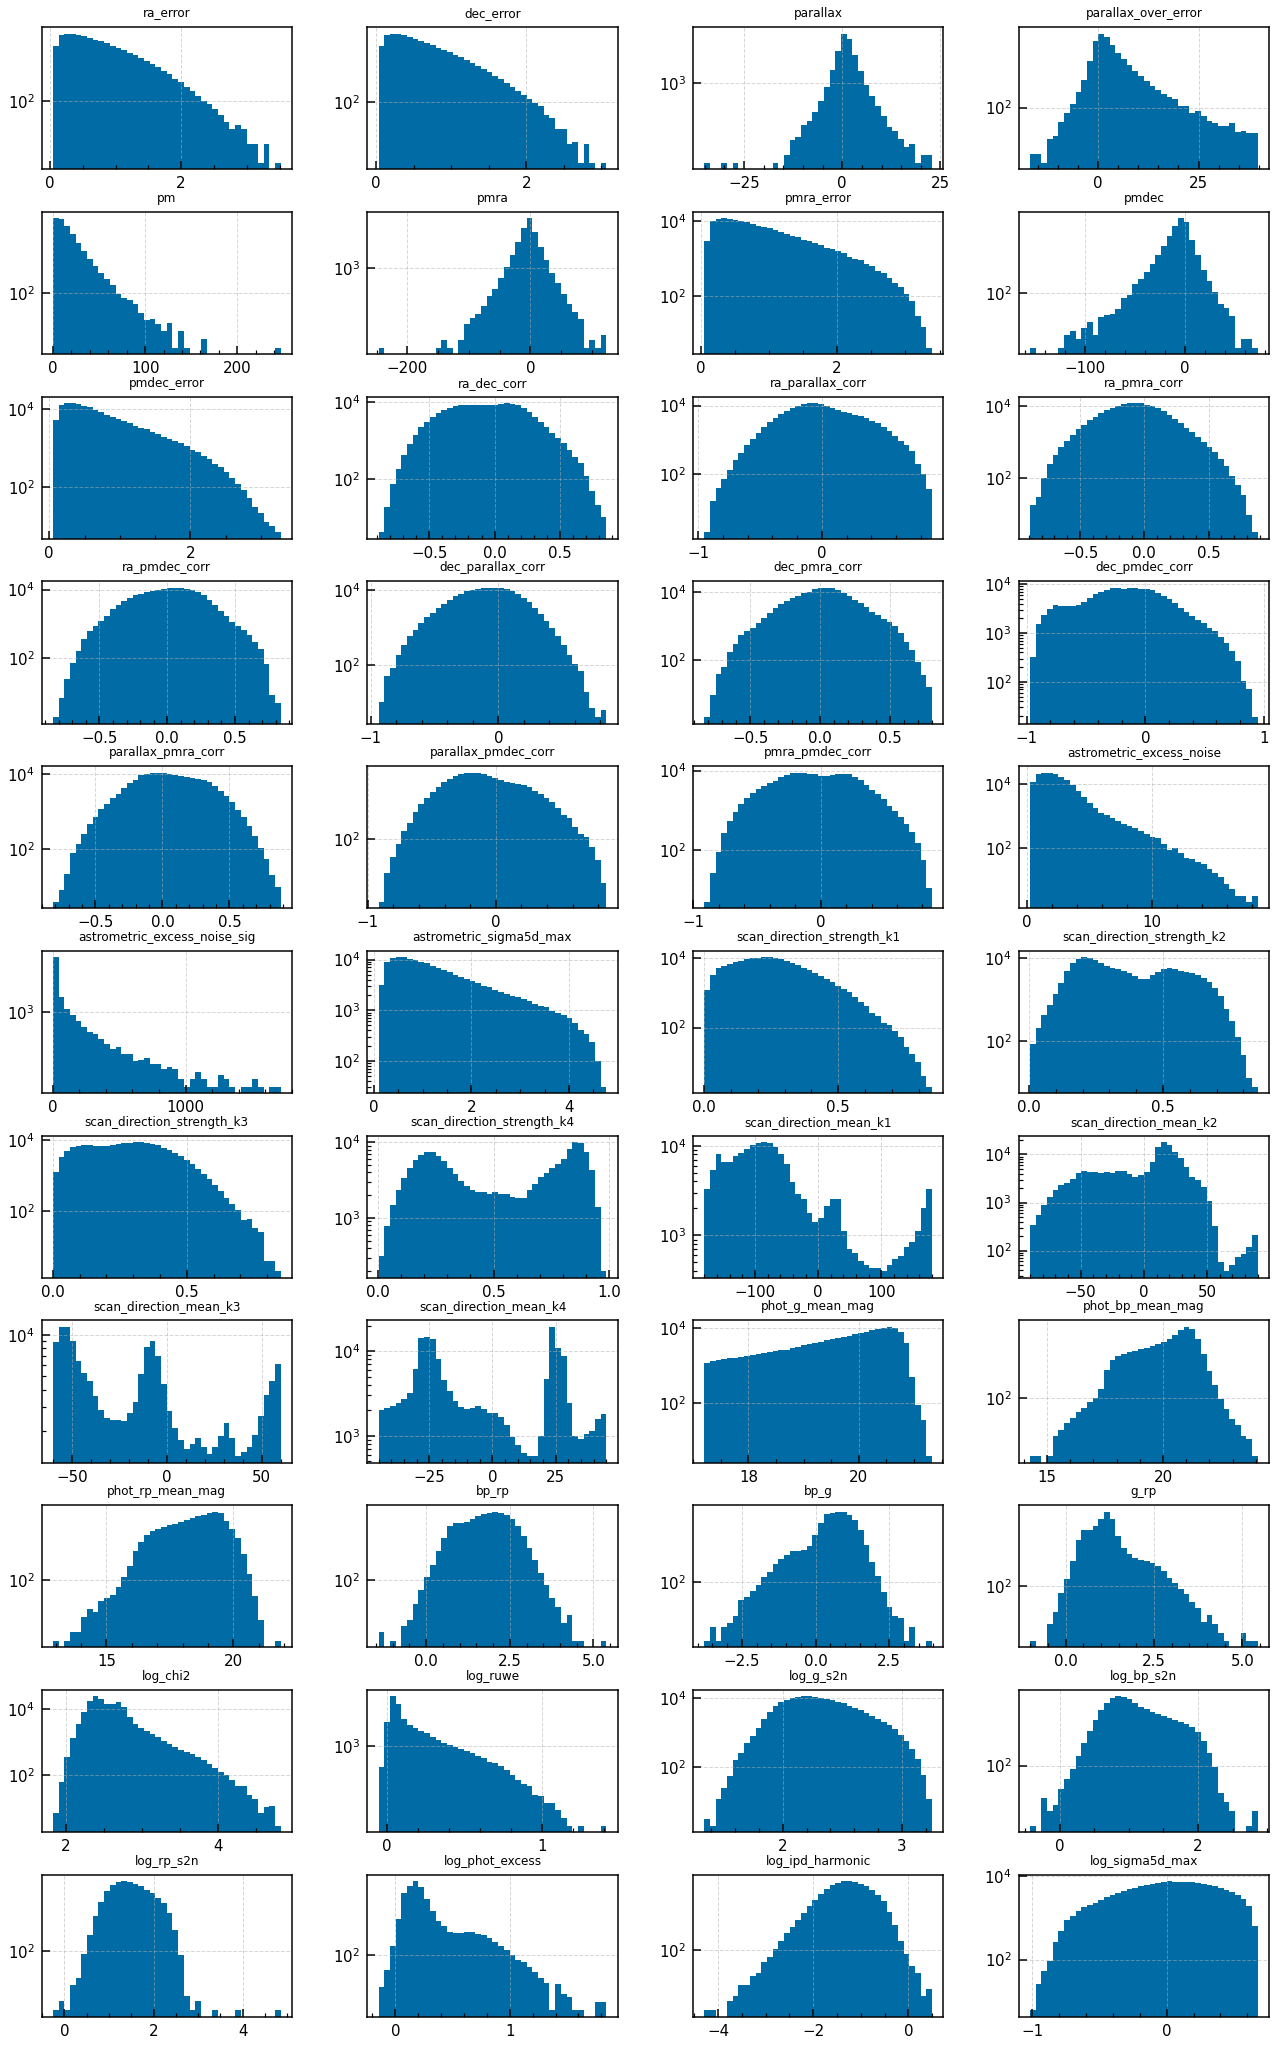

In [93]:
_ = hsc_ml_data.hist(figsize=(22, 40), xlabelsize=15, ylabelsize=15, layout=(12, 4), bins=40, log=True)

In [94]:
hsc_ml_arr.shape

(157760, 44)

In [95]:
tsne = manifold.TSNE(n_components=2, init='random', random_state=0, perplexity=30)

Y = tsne.fit_transform(hsc_ml_arr)

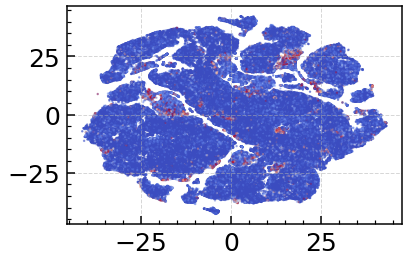

In [100]:
plt.scatter(Y[:, 0], Y[:, 1], s=2, alpha=0.3, c=hsc_ml['log_phot_excess'], cmap='coolwarm', vmin=0.2, vmax=0.8)